# <font color="FF4500" >第一阶段 自动微分 </font>

## <font color="7B68EE">步骤1 作为“箱子”的变量 </font>

### <font color="#008080"> 1.1 什么是变量 </font>

- “箱子”和数据是不同的东西
- “箱子”里可以存放数据（=赋值）
-  朝“箱子”里看一看就能知道数据是什么（=引用）

### <font color="#008080"> 1.2 实现Variable类 </font>

In [ ]:
class Variable:
    def __init__(self, data):
        # def __init__(self, data) 是类的构造函数（初始化方法）
        # 当创建 Variable 实例时自动调用，用于给新对象设置初始状态
        # 这里的 self 代表实例本身，data 是外部传入的初始化参数
        self.data = data  # 将外部传入的 data 赋值给实例属性 data


In [2]:
import numpy as np

data = np.array(1.0)
x = Variable(data)
x.data

array(1.)

In [3]:
x.data = np.array(2.0)
x.data

array(2.)

- x是Variable的一个实例，是存放数据的实体，是一个存放数据的“箱子”。x不是数据，数据存在x这个“箱子”里，数据可以从箱子中读取和更改。

### <font color="#008080"> 1.3 Numpy的多维数组 </font>

- 机器学习使用多维数组（张量）作为底层数据结构。标量是零维张量，向量是一维张量，矩阵是二维张量。

<font color="#C71585">**！！！请注意区分向量的维度和数组的维度。向量的维度指的是向量中元素的数量，但在提到三维数据时，数组的维度指的是轴的数量是3.**

## <font color="7B68EE">步骤2 创建变量的函数

### <font color="#008080"> 2.1 什么是函数 </font>

- 函数具有定义变量之间对应关系的作用
- 用节点和箭头来表示计算的图，叫做计算图
- 用圆框表示变量，方框表示函数

### <font color="#008080"> 2.2 Function类的实现 </font>

In [4]:
class Function:
    def __call__(self, input):
        x = input.data  # pick the data
        y = x ** 2  # the function we need
        output = Variable(y)  # return as a Variable instance
        return output

- call方法是一个特殊的 Python 方法。定义了这个方法后,当 f = Function()时,就可以通过编写f(...)来调用call方法了

### <font color="#008080"> 2.3 使用Function类 </font>

In [5]:
x = Variable(np.array(10))
f = Function()
y = f(x)

type(y), y.data

(__main__.Variable, 100)

In [6]:
print(type(y))
print(y.data)

<class '__main__.Variable'>
100


- Function类作为基类，实现所有函数通用的功能。Function类将函数与Variable类结合了起来。
- 具体需要实现的函数，在继承Function类的子类中实现

**重新设计Function类：**

In [ ]:
class Function:
    def __call__(self, input):
        x = input.data
        y = self.forward(x)
        output = Variable(y)
        return output
    
    def forward(self, x):
        raise NotImplementedError()

- 新的Function类中，实现了call和forward两个方法。call方法执行两项任务: 从**Variable**中**取出**数据和将计算结果**保存**到Variable中。
- 具体的计算通过调用forward方法完成
- forward方法的实现在**继承类**中完成

**设计一个Square继承类：**

In [8]:
class Square(Function):
    def forward(self, x):
        return x ** 2

In [9]:
x = Variable(np.array(10))
f = Square()
y = f(x)

type(y), y.data

(__main__.Variable, 100)

## <font color="7B68EE">步骤3 函数的连续调用

### <font color="#008080"> 3.1 Exp函数的实现

**完成exp函数：**

In [10]:
class Exp(Function):
    def forward(self, x):
        return np.exp(x)

### <font color="#008080"> 3.2 函数的连续调用

- Function类的call方法的输入和输出都是Variable实例，因此函数可以连续调用

In [11]:
A = Square()
B = Exp()
C = Square()

x = Variable(np.array(0.5))
a = A(x)
b = B(a)
y = C(b)

y.data

1.648721270700128

## <font color="7B68EE"> 步骤4 数值微分

### <font color="#008080"> 4.1 什么是导数

**已经实现了Variable类(用于存储变量)和Function类(用于实现运算)，目的是实现自动微分。并从数值微分(numerical differentiation)过度到实现反向传播。**

**导数的定义：** \begin{equation} f^{\prime}(x)=\lim _{h \rightarrow 0} \frac{f(x+h)-f(x)}{h} \end{equation}

In [12]:
%%html
<img src='4.1_numerical_differentiation.png', width='60%'>

### <font color="#008080"> 4.2 数值微分的实现

**中心差分近似是减小近似值误差的一种方法。中心差分近似计算的不是$f(x)$和$f(x+h)$的差，而是$f(x-h)$和$f(x+h)$的差。**

In [13]:
%%HTML
<img src='4.2_Central_Difference_Approximation.png', width='60%'>

**中心差分近似**$$f^{\prime}(x)=\lim _{h \rightarrow 0} \frac{f(x+h)-f(x-h)}{2 h}$$

**计算过$x$和$x+h$这两点的直线的斜率的方法称为前向差分近似，计算$x − h$和$x + h$这两点间斜率的方法称为中心差分近似，中心差分近似实际产生的误差更小。这一点的证明超出了本书的范围，不过我们从图4-2中直线的斜率可以直观地得出这个结论。**

**实现数值微分：**

- 参数f是被求导的函数，是Function 类的实例。
- 参数x为求导的变量，是Variable类的实例。

In [14]:
def numerical_diff(f, x, eps=1e-4):
    x0 = Variable(x.data - eps)
    x1 = Variable(x.data + eps)
    y0 = f(x0)
    y1 = f(x1)
    return (y1.data - y0.data) / (2 * eps)

In [ ]:
f = Square()
x = Variable(np.array(2.0))
dy = numerical_diff(f, x)
dy

4.000000000004

### <font color="#008080"> 4.3 复合函数的导数

In [ ]:
def f(x):
    A = Square()
    B = Exp()
    C = Square()
    return C(B(A(x)))

x = Variable(np.array(0.5))
dy = numerical_diff(f, x)
dy
#他算导数的时候用的是数值微分，也就是那个x+h  x-h的方法（中心差分近似）

3.2974426293330694

**运行上面的代码，得到的导数是3.297...。这意味着，如果x从0.5变成一个微小的值，y值的变化幅度将是这个微小值的3.297...倍。**

**成功实现 “自动” 求导。只要用<font color="#C71585">代码来定义要完成的计算</font> ，程序就会自动求出导数。使用这种方法，无论多么复杂的函数组合，程序都能自动求出导数。**

### <font color="#008080"> 4.4 数值微分存在的问题

**1.数值微分的结果中容易包含误差的主要原因是 <font color="#C71585">“精度丢失” </font>。中心差分近似等求差值的方法计算的是相同量级数值之间的差，但由于精度丢失，计算结果中会出现有效位数减少的情况。**

**2.数值微分更严重的问题是<font color="#C71585">计算成本高</font>。具体来说， 在求多个变量的导数时， 程序需要计算每个变量的导数。有些神经网络包含几百万个以上的变量 （ 参数 ） ， 通过数值微分对这么多的变量求导是不现实的。**

**数值微分可以轻松实现，并能计算出大体正确的数值。而反向传播是一种复杂的算法，实现时容易出现bug。可以使用数值微分的结果检查反向传播的实现是否正确。这种做法叫作<font color="#C71585">梯度检验 （ gradient checking ） </font>，可以将数值微分的结果与反向传播的结果进行比较。**

## <font color="7B68EE"> 步骤5 反向传播的理论知识

**数值微分在计算成本和精度方面存在问题。反向传播可以解决这两个问题。也就是说，反向传播不仅能高效地求导，还能帮助我们得到误差更小的值。**

### <font color="#008080"> 5.1 链式法则

**假设有一个函数$y = F(x)$,这个函数F由3个函数组成:$a = A(x)$、 $b = B(a)$和$y = C(b)$。**

In [5]:
%%HTML
<img src='5.1_composite_function.png', width='80%'>

- 圆圈表示变量，方框表示函数
- 正向传播时，框架不仅会计算出该节点的输出传给下一个节点，还会把计算局部导数所需的原始输入数据缓存（Cache）在内存/显存中，以备在反向传播时进行局部敏感度（局部梯度）的计算。
- 这也是训练模型（Training）比单纯使用模型推理（Inference）要消耗大得多显存（GPU Memory） 的原因，推理不需要进行反向传播，不需要保存中间变量。

**$y$对$x$的导数$$\frac{\mathrm{d} y}{\mathrm{~d} x}=\frac{\mathrm{d} y}{\mathrm{~d} y} \frac{\mathrm{~d} y}{\mathrm{~d} b} \frac{\mathrm{~d} b}{\mathrm{~d} a} \frac{\mathrm{~d} a}{\mathrm{~d} x}$$**

### <font color="#008080"> 5.2 反向传播的推导

**链式法则的计算顺序**$$\frac{\mathrm{d} y}{\mathrm{~d} x}=\left(\left(\frac{\mathrm{d} y}{\mathrm{~d} y} \frac{\mathrm{~d} y}{\mathrm{~d} b}\right) \frac{\mathrm{d} b}{\mathrm{~d} a}\right) \frac{\mathrm{d} a}{\mathrm{~d} x}$$

**从输出到输入的计算流程**

In [4]:
%%HTML
<img src='5.2_‌Derivative_calculatio_process‌.png', width='80%'>

**反向传播的计算图：**

In [2]:
%%HTML
<img src='5.3_Back_Propagation_Computational_Graph.png', width='80%'>

- 反向传播时，计算的是各层的局部敏感度，图中，上层的$\frac{\mathrm{d} a}{\mathrm{~d} x}$、$\frac{\mathrm{d} b}{\mathrm{~d} a}$、$\frac{\mathrm{d} y}{\mathrm{~d} b}$为局部敏感度
- “局部敏感度”（局部导数、局部梯度）指的是某个具体操作节点（正向传播时的函数）的输出对其直接输入的偏导数。它只与当前的运算步骤有关，与图中的其他部分无关。
- 最终的梯度$\frac{\mathrm{d} y}{\mathrm{~d} x}$，由链式法则，在图中，从右向左逐级相乘得到。

- 从这种梯度计算的方式，大家会想到什么？
- 如果网络很深，这种连乘的计算，会很容易导致训练中的两种现象：梯度消失、梯度爆炸
- 怎么办？如何让局部敏感度乖乖保持在 1 附近！（且听下回详细分解）

### <font color="#008080"> 5.3 用计算图表示

In [1]:
%%HTML
<img src='5.5_Forward_propagation_and_backpropagation.png', width='80%'>

**从计算图可以看出，在前向传播和反向传播中，变量（圆圈）和函数（方框）均具有一一对应的关系；我们可以认为变量有<font color="#C71585">普通值和导数值</font>，函数有<font color="#C71585">普通计算（正向传播）和求导计算（反向传播）</font>。**

**实现反向传播时，需要先进行正向传播，并且存储各函数输入的变量值**

##  <font color="7B68EE"> 步骤6 手动进行反向传播

### <font color="#008080"> 6.1 Variable类的功能扩展

**扩展Variable类, 除普通值 (data) 之外, 增加与之对应的导数值 (grad) 。**

In [21]:
class Variable:
    def __init__(self, data):
        self.data = data
        self.grad = None   # 新增属性，初始化为None，通过反向传播实际计算导数时将其设置为求出的值

### <font color="#008080"> 6.2 Function类的功能扩展

**Function类已经实现普通计算的正向传播 （forward方法 ） 的功能。在此基础上，新增以下两个功能：**

- **计算导数的反向传播 (backward方法 ) 功能**
- **调用forward方法时,保存被输入的Variable实例的功能**

In [22]:
class Function:
    def __call__(self, input):
        x = input.data
        y = self.forward(x)
        output = Variable(y)
        self.input = input  # 保存输入的变量
        return output
    
    def forward(self, x):
        raise NotImplementedError()
        
    def backward(self, gy):
        raise NotImplementedError() # 反向传播

### <font color="#008080"> 6.3 Square类和Exp类的功能扩展

**$y = x^{2}$的导数是$$\frac{dy}{dx}=2x$$**

In [23]:
class Square(Function):
    def forward(self, x):
        y = x ** 2
        return y
    
    def backward(self, gy):
        x = self.input.data
        gx = 2 * x * gy
        return gx

**$y = e^{x}$的导数$$\frac{dy}{dx}=e^{x}$$**

In [24]:
class Exp(Function):
    def forward(self, x):
        y = np.exp(x)
        return y
    
    def backward(self, gy):
        x = self.input.data
        gx = np.exp(x) * gy
        return gx

### <font color="#008080"> 6.4 反向传播的实现

**实现下面计算图的反向传播**

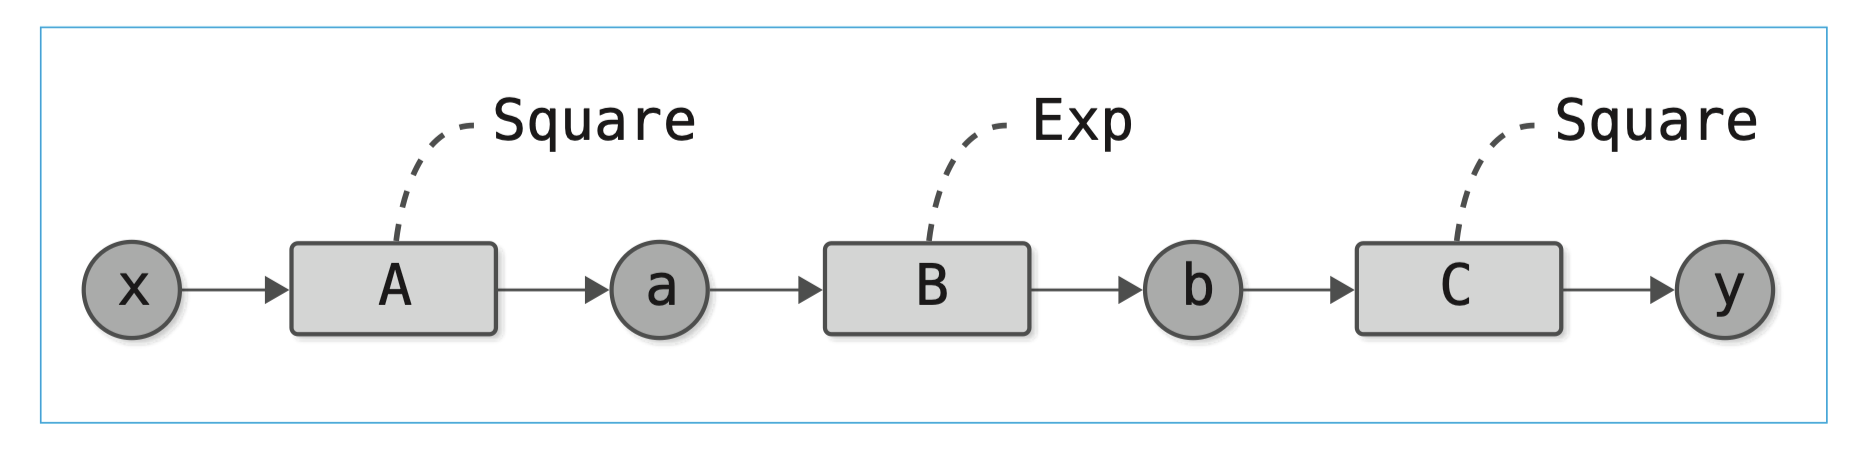

In [25]:
A = Square()
B = Exp()
C = Square()

x = Variable(np.array(0.5))
a = A(x)
b = B(a)
y = C(b)

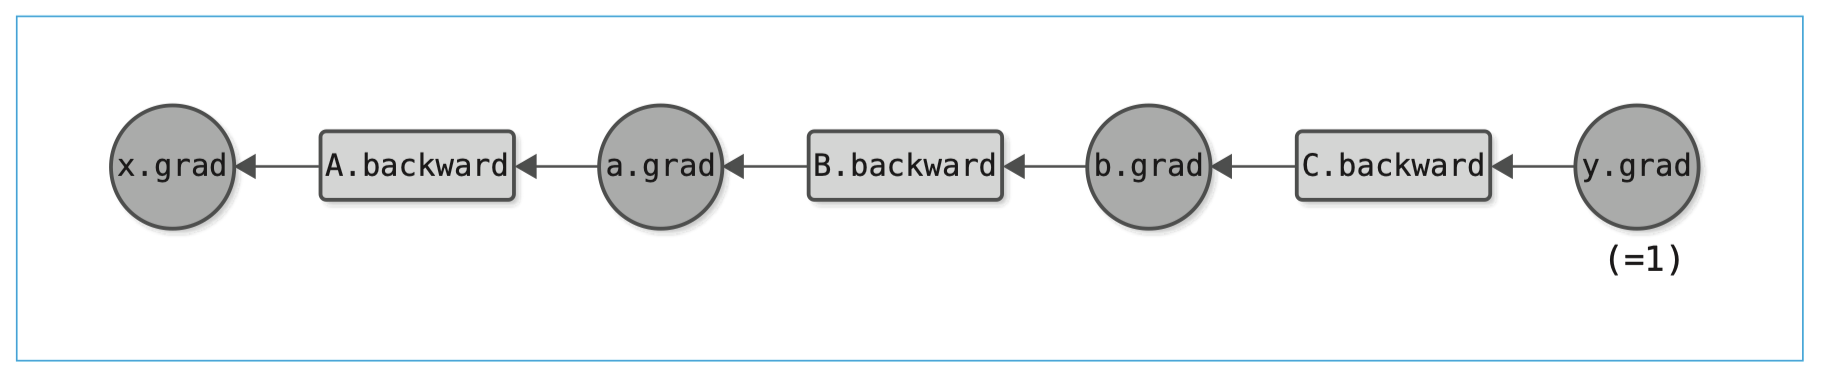

In [26]:
y.grad = np.array(1.0)
b.grad = C.backward(y.grad)
a.grad = B.backward(b.grad)
x.grad = A.backward(a.grad)
x.grad

3.297442541400256

## <font color="7B68EE"> 步骤7 反向传播的自动化

**让反向传播自动化，就是要建立这样一个机制：<font color="#C71585">无论普通的计算流程（正向传播）中是什么样的计算，反向传播都能自动进行</font>。我们马上要接触到Define－by－Run的核心了。**

**Define－by－Run是深度学习在计算之间建立 “连接” 的机制，这种机制称为<font color="#C71585">动态计算图</font>。关于Define－by－Run及其优点的详细信息， 参考步骤24。**

### <font color="#008080"> 7.1 为反向传播的自动化创造条件

**思考：变量和函数之间的关系。**

**从<font color="#C71585">函数的角度看待变量</font>：从函数的角度来看，变量是以输入和输出的形式存在的**

**从<font color="#C71585">变量的角度看待函数</font>：变量是由函数“创造”的；函数是变量的“父母”，是creator（创造者）。用户给出的变量，是没有创造者的变量。**

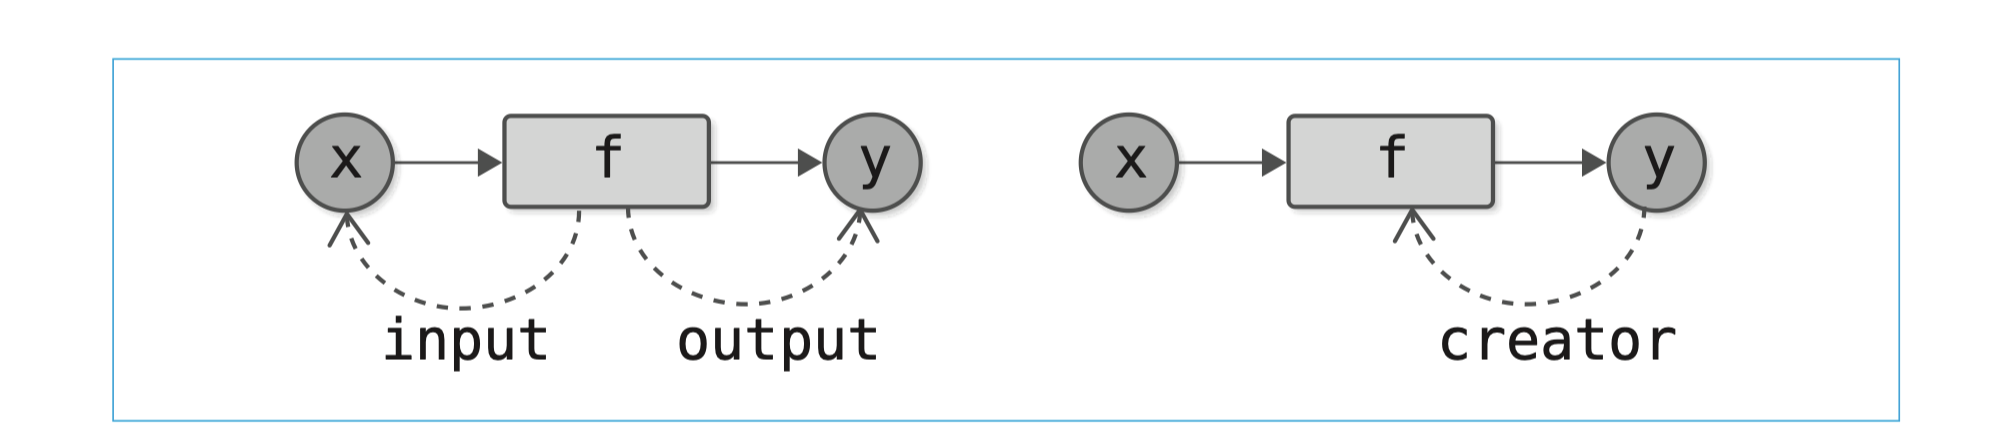

In [33]:
class Variable:
    def __init__(self, data):
        self.data = data
        self.grad = None
        self.creator = None  # 在执行普通计算（正向传播）时创建函数和变量之间的 “连接”
        
    def set_creator(self, func):
        self.creator = func

**变量是函数“创造”的，函数是变量的“父母”，是creator（创造者）**

In [34]:
class Function:
    def __call__(self, input):
        x = input.data
        y = self.forward(x)
        output = Variable(y)
        output.set_creator(self)  # 让输出变量保存创造者信息,为Function的输出添加创造函数属性
        self.input = input
        self.output = output   # 也保存输出变量
        return output

In [37]:
class Square(Function):     
    def forward(self, x):         
        y = x ** 2         
        return y     
    def backward(self, gy):         
        x = self.input.data         
        gx = 2 * x * gy         
        return gx

In [38]:
class Exp(Function):     
    def forward(self, x):         
        y = np.exp(x)         
        return y     
    def backward(self, gy):         
        x = self.input.data         
        gx = np.exp(x) * gy         
        return gx

**<font color="#C71585">DeZero的动态计算图的原理是在执行实际的计算时，在变量这个 “箱子”里记录它的 “连接” 。Chainer和PyTorch也采用了类似的机制。</font>**

In [39]:
A = Square() 
B = Exp() 
C = Square() 

x = Variable(np.array(0.5)) 
a = A(x) 
b = B(a) 
y = C(b) 

# 反向遍历计算图的节点
assert y.creator == C 
assert y.creator.input == b 
assert y.creator.input.creator == B 
assert y.creator.input.creator.input == a 
assert y.creator.input.creator.input.creator == A 
assert y.creator.input.creator.input.creator.input == x

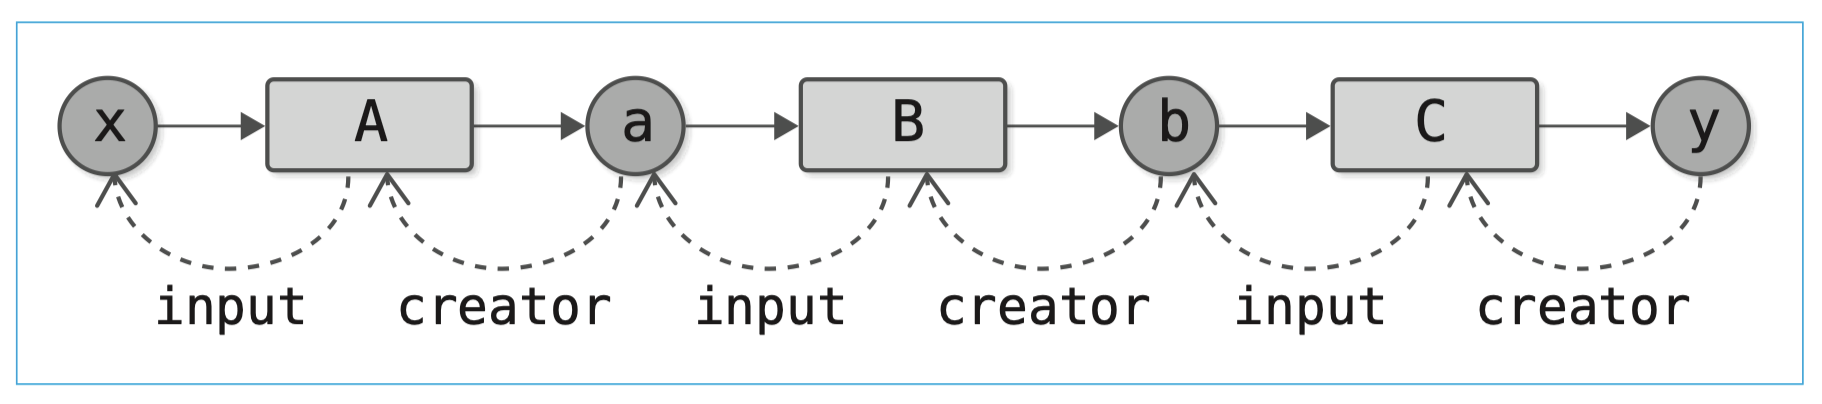

**计算图是由函数和变量之间的 “连接” 构建而成的。更重要的是，这个 “连接” 是在计算实际发生的时候（数据在正向传播中流转的时候）形成的。变量和函数连接的这个特征就是Define－by－Run。<font color="#C71585">“连接”是通过数据的流转建立起来的。</font>**

### <font color="#008080"> 7.2 尝试反向传播

In [47]:
y.grad = np.array(1.0) 
C = y.creator  # 1. 获取函数
b = C.input  # 2. 获取函数的输入
b.grad = C.backward(y.grad)  # 3. 调用函数的backward方法
b.grad

2.568050833375483

In [48]:
B = b.creator  # 1. 获取函数
a = B.input  # 2. 获取函数的输入
a.grad = B.backward(b.grad)  # 3. 调用函数的backward方法
a.grad

3.297442541400256

In [49]:
A = a.creator  # 1. 获取函数
x = A.input  # 2. 获取函数的输入
x.grad = A.backward(a.grad)  # 3. 调用函数的backward方法
x.grad

3.297442541400256

- **1． 获取函数**
- **2． 获取函数的输入**
- **3． 调用函数的backward方法**

### <font color="#008080"> 7.3 增加backward方法

In [50]:
class Variable:
    def __init__(self, data):
        self.data = data
        self.grad = None
        self.creator = None
        
    def set_creator(self, func):
        self.creator = func
        
    def backward(self):
        f = self.creator  # 1.获取函数
        if f is not None:
            x = f.input  # 2.获取函数的输入
            x.grad = f.backward(self.grad)  # 3.调用函数的backward方法
            x.backward()  # 调用自己前面那个变量的backward方法（递归）

**backward方法调用了（朝着输入方向的）前一个变量的backward方法。由此，“backward方法内调用backward方法，被调用的backward方法内再次调用backward方法”的处理会不断延续下去（直到碰到一个self.creator函数为None的Variable变量）。这是一个递归结构。**

In [51]:
A = Square()
B = Exp()
C = Square()

x = Variable(np.array(0.5))
a = A(x)
b = B(a)
y = C(b)

y.grad = np.array(1.0)
y.backward()
x.grad

3.297442541400256

## <font color="7B68EE"> 步骤8 从递归到循环

### <font color="#008080"> 8.1 现在的Variable类

In [50]:
class Variable:
    def __init__(self, data):
        self.data = data
        self.grad = None
        self.creator = None
        
    def set_creator(self, func):
        self.creator = func
        
    def backward(self):
        f = self.creator  # 1.获取函数
        if f is not None:
            x = f.input  # 2.获取函数的输入
            x.grad = f.backward(self.grad)  # 3.调用函数的backward方法
            x.backward()  # 调用自己前面那个变量的backward方法（递归）

**使用递归结构实现的Variable类**

### <font color="#008080"> 8.2 使用循环实现

In [52]:
class Variable:
    def __init__(self, data):
        self.data = data
        self.grad = None
        self.creator = None
        
    def set_creator(self, func):
        self.creator = func
        
    def backward(self):
        funcs = [self.creator]
        while funcs:
            f = funcs.pop()   # 获取funcs函数列表的最后一个元素赋值给f，并将这个元素从funcs列表中删除
            x, y = f.input, f.output  # 获取函数的输入
            x.grad = f.backward(y.grad)  # backward调用backward方法
            
            if x.creator is not None:
                funcs.append(x.creator)  # 将前一个函数添加到列表中
            

### <font color="#008080"> 8.3 代码验证

In [53]:
A = Square()
B = Exp()
C = Square()

x = Variable(np.array(0.5))
a = A(x)
b = B(a)
y = C(b)

y.grad = np.array(1.0)
y.backward()
x.grad

3.297442541400256

**使用循环，会让代码实现很容易扩展到复杂的计算图的处理，而且循环的执行效率也会变高。**

**每次递归调用函数时，函数都会将处理过程中的结果保留在内存中 （ 或者说保留在栈中 ） ，然后继续处理。因此一般来说，循环的效率更高。不过， 对现代计算机来说，使用少量的内存是没有问题的。有时可以通过尾递归的技巧，使递归处理能够按照循环的方式执行。**

## <font color="7B68EE"> 步骤9 让函数更易用

### <font color="#008080"> 9.1 作为Python函数使用

In [54]:
def square(x):     
    return Square()(x)  
def exp(x):     
    return Exp()(x)

In [55]:
x = Variable(np.array(0.5)) 
a = square(x) 
b = exp(a) 
y = square(b) 

y.grad = np.array(1.0) 
y.backward() 
print(x.grad)

3.297442541400256


In [56]:
x = Variable(np.array(0.5)) 
y = square(exp(square(x)))  # 连续调用
y.grad = np.array(1.0) 
y.backward() 
print(x.grad)

3.297442541400256


### <font color="#008080"> 9.2 简化backward方法

In [57]:
class Variable:
    def __init__(self, data):
        self.data = data
        self.grad = None
        self.creator = None
        
    def set_creator(self, func):
        self.creator = func
        
    def backward(self):
        if self.grad is None:             
            self.grad = np.ones_like(self.data)  # 如果梯度为None，自动生成导数
        
        funcs = [self.creator]
        while funcs:
            f = funcs.pop()   # 获取funcs函数列表的最后一个元素赋值给f，并将这个元素从funcs列表中删除
            x, y = f.input, f.output  # 获取函数的输入
            x.grad = f.backward(y.grad)  # backward调用backward方法
            
            if x.creator is not None:
                funcs.append(x.creator)  # 将前一个函数添加到列表中
            

In [58]:
x = Variable(np.array(0.5)) 
y = square(exp(square(x)))  
y.backward() 
print(x.grad)

3.297442541400256


### <font color="#008080"> 9.3 只支持ndarray

In [59]:
class Variable:
    def __init__(self, data):
        if data is not None:             
            if not isinstance(data, np.ndarray):                
                raise TypeError('{} is not supported'.format(type(data)))
                
        self.data = data
        self.grad = None
        self.creator = None
        
    def set_creator(self, func):
        self.creator = func
        
    def backward(self):
        if self.grad is None:             
            self.grad = np.ones_like(self.data)  # 如果梯度为None，自动生成导数
        
        funcs = [self.creator]
        while funcs:
            f = funcs.pop()   # 获取funcs函数列表的最后一个元素赋值给f，并将这个元素从funcs列表中删除
            x, y = f.input, f.output  # 获取函数的输入
            x.grad = f.backward(y.grad)  # backward调用backward方法
            
            if x.creator is not None:
                funcs.append(x.creator)  # 将前一个函数添加到列表中

In [60]:
x = Variable(np.array(1.0))  # OK

In [61]:
x = Variable(None)  # OK

In [62]:
# x = Variable(1.0)  # NG:错误发生!

TypeError: <class 'float'> is not supported

**<font color="#C71585">Numpy本身带来的数据类型问题：0维ndarray数据运算后不再是ndarray类型!!!</font>**

In [63]:
x = np.array([1.0]) 
y = x ** 2 
print(type(x), x.ndim) 
print(type(y))

<class 'numpy.ndarray'> 1
<class 'numpy.ndarray'>


In [65]:
x = np.array(1.0) 
y = x ** 2 
print(type(x), x.ndim) 
print(type(y))

<class 'numpy.ndarray'> 0
<class 'numpy.float64'>


In [66]:
def as_array(x):     
    if np.isscalar(x):         
        return np.array(x)     
    return x

In [68]:
class Function:
    def __call__(self, input):
        x = input.data
        y = self.forward(x)
        output = Variable(as_array(y))
        output.set_creator(self)  # 让输出变量保存创造者信息,为Function的输出添加创造函数属性
        self.input = input
        self.output = output   # 也保存输出变量
        return output

## <font color="7B68EE"> 步骤10 测试

### <font color="#008080"> 10.1 Python的单元测试

In [69]:
import unittest 
class SquareTest(unittest.TestCase):     
    def test_forward(self):         
        x = Variable(np.array(2.0))         
        y = square(x)         
        expected = np.array(4.0)         
        self.assertEqual(y.data, expected)

### <font color="#008080"> 10.2 square函数反向传播的测试

In [ ]:
class SquareTest(unittest.TestCase):     
    def test_forward(self):   
        x = Variable(np.array(2.0))         
        y = square(x)         
        expected = np.array(4.0)         
        self.assertEqual(y.data, expected)
        
    def test_backward(self):         
        x = Variable(np.array(3.0))         
        y = square(x)        
        y.backward()         
        expected = np.array(6.0)         
        self.assertEqual(x.grad, expected)

### <font color="#008080"> 10.3 通过梯度检验来自动测试

**梯度检验（gradient checking）：梯度检验是将数值微分得到的结果与反向传播得到的结果进行比较。**

In [73]:
def numerical_diff(f, x, eps=1e-4):     
    x0 = Variable(x.data - eps)     
    x1 = Variable(x.data + eps)     
    y0 = f(x0)     
    y1 = f(x1)     
    return (y1.data - y0.data) / (2 * eps)

class SquareTest(unittest.TestCase):     
    def test_forward(self):   
        x = Variable(np.array(2.0))         
        y = square(x)         
        expected = np.array(4.0)         
        self.assertEqual(y.data, expected)
        
    def test_backward(self):         
        x = Variable(np.array(3.0))         
        y = square(x)        
        y.backward()         
        expected = np.array(6.0)         
        self.assertEqual(x.grad, expected)
            
    def test_gradient_check(self):         
        x = Variable(np.random.rand(1))  # 生成随机的输入值
        y = square(x)        
        y.backward()         
        num_grad = numerical_diff(square, x)         
        flg = np.allclose(x.grad, num_grad)         
        self.assertTrue(flg)

### <font color="#008080"> 10.4 测试小结

In [76]:
# $ python -m unittest discover tests

**discover会在其后指定的目录下搜索测试文件，然后将所有找到的文件一起运行。在默认情况下，指定目录下符合test＊．py模式的文件会被识别为测试文件 （ 模式可以修改 ） 。这样就能一次性运行tests目录下的所有测试文件了。**

## <font color="7B68EE"> 专栏 自动微分

**自动微分可以大体分为两种：前向模式的自动微分和反向模式的自动微分。**